In [91]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [92]:
import random as rd
import time

In [121]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [94]:
def create_matrix(Din,DigitosPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(DigitosPorSimbolo-1),1*6**(DigitosPorSimbolo))
      Bin[i][j] = rd.randint(1*(DigitosPorSimbolo-1),1*6**(DigitosPorSimbolo))
  return [Ain,Bin]

In [95]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [96]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [97]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [98]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")

  if(flag):
    s = serial.Serial()
    s.port = "/dev/ttyUSB1"
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
  Fs =10000
  cmp = len(str(X[0][0]))
  file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    strbin = ''
    for j in range(X.shape[0]):
      if(X[j][i] ==0):
        strbin+=str(X[j][i])
      else:
        strbin+=str(X[j][i])
    print('0b'+strbin,i)
    print(int('0b'+strbin,2))
    file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    if(flag):
      s.write(bytearray([int('0b'+strbin,2)]))
      time.sleep(1/Fs)  
  if(flag):
    s.write(bytearray([255]))
    s.close()  
  file.close()
  

In [99]:
M = create_matrix(Din = 8, DigitosPorSimbolo=1)
M[1]

array([[0, 0, 5, 7, 7, 5, 7, 3],
       [3, 5, 7, 0, 9, 6, 2, 6],
       [6, 3, 7, 1, 4, 0, 8, 3],
       [1, 2, 9, 3, 6, 4, 0, 4],
       [1, 0, 2, 0, 6, 3, 9, 9],
       [3, 5, 6, 0, 4, 2, 5, 3],
       [4, 6, 6, 2, 5, 8, 4, 2],
       [1, 8, 2, 0, 7, 2, 4, 1]])

In [100]:
M[0]@M[1]

array([[124, 156, 281, 103, 290, 205, 254, 193],
       [111, 154, 266,  67, 262, 141, 210, 177],
       [ 46, 106, 123,  48, 174, 105, 135,  99],
       [ 64, 116, 162,  65, 188, 132, 136,  98],
       [ 81, 124, 184,  29, 178, 111, 143, 131],
       [ 52,  90, 119,  32, 116,  67,  78,  55],
       [ 81, 174, 200,  52, 214, 156, 138, 109],
       [108, 151, 217,  80, 203, 142, 184,  99]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [101]:
M[1]@M[0]

array([[125, 121,  77, 124,  62, 181, 169, 166],
       [130, 111, 167, 192, 118, 182, 182, 181],
       [151, 126, 110, 147, 107, 179, 192, 162],
       [114,  90, 101, 113,  82, 123, 124, 142],
       [103,  78, 111, 141,  53, 168, 201, 157],
       [112,  98, 111, 143,  92, 148, 144, 145],
       [138, 127, 147, 184, 107, 174, 168, 179],
       [ 71,  92, 110, 157,  93, 159, 106, 120]])

In [102]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    
    break
    time.sleep(10)

---------------------- 0 --------------------------


SerialException: [Errno 5] could not open port /dev/ttyUSB1: [Errno 5] Input/output error: '/dev/ttyUSB1'

In [103]:
M[0]@M[1]

array([[124, 156, 281, 103, 290, 205, 254, 193],
       [111, 154, 266,  67, 262, 141, 210, 177],
       [ 46, 106, 123,  48, 174, 105, 135,  99],
       [ 64, 116, 162,  65, 188, 132, 136,  98],
       [ 81, 124, 184,  29, 178, 111, 143, 131],
       [ 52,  90, 119,  32, 116,  67,  78,  55],
       [ 81, 174, 200,  52, 214, 156, 138, 109],
       [108, 151, 217,  80, 203, 142, 184,  99]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]]))

In [113]:
M = create_matrix(Din = 16, DigitosPorSimbolo=1)

In [105]:
M[0]@M[1]

array([[604, 738, 714, ..., 628, 789, 762],
       [716, 924, 870, ..., 855, 877, 944],
       [664, 694, 654, ..., 644, 743, 785],
       ...,
       [541, 617, 747, ..., 677, 673, 721],
       [613, 706, 688, ..., 532, 709, 777],
       [615, 618, 627, ..., 644, 689, 826]], shape=(32, 32))

In [106]:
M

[array([[3, 8, 1, ..., 2, 5, 8],
        [2, 8, 8, ..., 3, 3, 7],
        [5, 9, 1, ..., 8, 3, 4],
        ...,
        [8, 2, 6, ..., 4, 0, 6],
        [7, 5, 0, ..., 6, 8, 8],
        [8, 3, 0, ..., 7, 3, 0]], shape=(32, 32)),
 array([[6, 2, 6, ..., 7, 9, 6],
        [0, 9, 4, ..., 4, 2, 1],
        [3, 4, 8, ..., 7, 7, 1],
        ...,
        [9, 7, 2, ..., 3, 7, 7],
        [7, 1, 4, ..., 1, 5, 6],
        [3, 9, 4, ..., 3, 6, 7]], shape=(32, 32))]

In [116]:
M_p[0]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 7, 1, 9, 1, 9, 9,
        9, 0, 0, 9, 0, 3, 2, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, 8, 4, 0, 8, 5, 8,
        3, 8, 1, 7, 7, 0, 9, 9, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 0, 6, 8, 7, 7, 5, 7,
        1, 1, 4, 2, 0, 6, 9, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 8, 8, 4, 8, 1, 1, 5, 4, 8,
        7, 6, 4, 3, 6, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 9, 9, 9, 1, 3, 1, 0, 7, 1, 8,
        3, 1, 2, 8, 4, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 7, 3, 2, 8, 9, 9, 0, 6, 7, 1, 6,
        0, 3, 8, 7, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 6, 7, 1, 6, 7, 5, 6, 5, 6, 3, 6, 8,
        5, 2, 3, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 2, 9, 8, 9, 2, 1, 0, 2, 8, 9, 9, 4,
        9, 3, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 3, 8, 4, 9, 4, 0, 2, 3, 4, 0, 0, 0, 7, 0, 6,
        4, 0, 0, 0, 0, 0, 0, 0, 0],
       [0,

In [108]:
M_p[1]

array([[0, 0, 0, 0, 0, 0, 0, 0, 3, 6, 1, 1, 3, 4, 1],
       [0, 0, 0, 0, 0, 0, 0, 5, 3, 2, 0, 5, 6, 8, 0],
       [0, 0, 0, 0, 0, 5, 7, 7, 9, 2, 6, 6, 2, 0, 0],
       [0, 0, 0, 0, 7, 0, 1, 3, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 7, 9, 4, 6, 6, 4, 5, 7, 0, 0, 0, 0],
       [0, 0, 5, 6, 0, 4, 3, 2, 8, 2, 0, 0, 0, 0, 0],
       [0, 7, 2, 8, 0, 9, 5, 4, 4, 0, 0, 0, 0, 0, 0],
       [3, 6, 3, 4, 9, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0]])

In [115]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
0000000000000009 0
0000000000000034 1
0000000000000626 2
0000000000009941 3
0000000000064225 4
0000000000312077 5
0000000005694601 6
0000000034404817 7
0000000380731777 8
0000001344684931 9
0000086293928233 10
0000477944095471 11
0001931803413369 12
0058926927414852 13
0158987235045221 14
9704195144165597 15
7868396006660290 16
1481105203463800 17
9071066806701000 18
1875773974750000 19
9554116907500000 20
9878868460000000 21
9317305940000000 22
0816132300000000 23
0144283000000000 24
9723870000000000 25
0706400000000000 26
3060000000000000 27
2990000000000000 28
0900000000000000 29
1000000000000000 30
0000000000000006 0
0000000000000032 1
0000000000000924 2
0000000000007776 3
0000000000098832 4
0000000000208696 5
0000000009622943 6
0000000059623623 7
0000000248494180 8
0000007329185821 9
0000016018958036 10
0000737556580972 11
0001011320621689 12
0080037815662870 13
0863350339841261 14
6232371962473996 15
6984944121141120 16
90064094

In [126]:
len(str("0000000000000009"))*4


64

In [ ]:
M_p[0]

array([[0, 0, 0, 0, 0, 0, 0, 3, 9, 2, 4, 3, 9, 2, 8],
       [0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 2, 5, 3, 2, 0],
       [0, 0, 0, 0, 0, 9, 1, 3, 2, 5, 1, 8, 3, 0, 0],
       [0, 0, 0, 0, 0, 2, 3, 1, 5, 1, 3, 3, 0, 0, 0],
       [0, 0, 0, 1, 0, 2, 5, 3, 5, 9, 4, 0, 0, 0, 0],
       [0, 0, 7, 5, 5, 4, 9, 7, 7, 8, 0, 0, 0, 0, 0],
       [0, 2, 9, 3, 7, 4, 7, 2, 3, 0, 0, 0, 0, 0, 0],
       [7, 5, 1, 3, 5, 2, 9, 1, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
M_p[1]

array([[0, 0, 0, 0, 0, 0, 0, 7, 3, 8, 0, 3, 8, 5, 4],
       [0, 0, 0, 0, 0, 0, 9, 0, 7, 0, 2, 6, 2, 0, 0],
       [0, 0, 0, 0, 0, 4, 0, 4, 7, 1, 9, 3, 9, 0, 0],
       [0, 0, 0, 0, 9, 2, 6, 1, 1, 1, 2, 9, 0, 0, 0],
       [0, 0, 0, 6, 5, 7, 4, 1, 4, 3, 1, 0, 0, 0, 0],
       [0, 0, 4, 5, 9, 8, 1, 6, 3, 9, 0, 0, 0, 0, 0],
       [0, 2, 2, 1, 2, 4, 7, 9, 8, 0, 0, 0, 0, 0, 0],
       [1, 4, 9, 0, 8, 9, 5, 9, 0, 0, 0, 0, 0, 0, 0]])

In [124]:
print_matrix(M[0]@M[1])

387 325 330 198 299 182 231 293 228 370 345 348 333 421 308 323 
453 362 353 211 391 326 319 356 255 394 446 402 375 483 432 317 
336 265 358 168 385 352 268 308 247 386 320 377 290 397 339 263 
423 373 247 223 278 232 393 233 258 392 358 348 295 475 434 222 
396 308 352 196 308 279 304 207 238 406 342 255 295 390 339 251 
486 427 375 195 443 401 355 319 264 408 400 442 332 493 383 258 
407 399 273 241 320 273 354 288 270 386 390 359 300 466 414 267 
450 369 298 327 405 303 287 306 278 392 354 429 278 476 484 341 
236 152 287 114 186 202 205 192 196 353 242 211 250 279 263 220 
316 293 249 197 293 226 272 257 240 322 325 342 254 358 357 229 
369 303 270 237 325 331 265 323 239 403 349 338 285 450 398 257 
353 377 224 242 293 202 285 276 236 332 317 340 299 464 387 282 
300 284 284 157 286 176 313 212 234 354 266 345 271 370 324 235 
432 397 318 216 378 309 340 354 269 374 375 411 352 539 401 276 
325 291 272 216 333 265 294 259 263 303 284 358 276 422 426 253 
300 324 320 208 334 252 3

In [ ]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])]

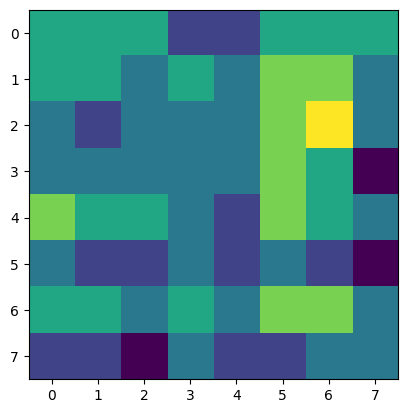

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",0)
    send_matrix(M_p[1],"IMPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
00000001 0
00000010 1
00000011 2
00000110 3
00001011 4
00111110 5
01101100 6
11010010 7
01011010 8
11101000 9
11111000 10
00110000 11
11100000 12
11000000 13
00000000 14
00000001 0
00000010 1
00000001 2
00000000 3
00000000 4
00010111 5
00010110 6
00001110 7
11110110 8
11001100 9
10100000 10
00100000 11
11000000 12
00000000 13
00000000 14


In [ ]:
M[0]

array([[1, 0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 0, 0, 1, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 0, 0]])

In [ ]:
M[1]

array([[0, 0, 0, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 1, 1, 0]])

In [ ]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [ ]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7f8d3cb31060, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)